<a href="https://colab.research.google.com/github/JTR2024/insurance-discourse-explorer/blob/gh-repo-clone-danny-avila%2FLibreChat/01_data_generation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Insurance Discourse Explorer: A Generative AI-Powered Sentiment Analysis

# Step 1: Environment Setup and Initial Configuration

# Let's use the existing OpenAI library instead of downgrading:
!pip install -q vaderSentiment==3.3.2 faiss-cpu==1.7.4

# Now, let's set up our environment and import necessary libraries:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import json
import re
from google.colab import drive
from google.colab import userdata  # For secure API key storage

# Set up plotting defaults
plt.style.use('ggplot')
sns.set(style="whitegrid")
%matplotlib inline

# Display environment information
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Set up working directories
# If using Google Drive:
# drive.mount('/content/drive')
# PROJECT_DIR = "/content/drive/MyDrive/insurance-discourse-explorer"
# Or just use Colab's temporary storage:
PROJECT_DIR = "/content"
DATA_DIR = f"{PROJECT_DIR}/data"

# Create data directory
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory: {DATA_DIR}")

# Configure OpenAI API Access securely
# The API key is stored in Colab's userdata where it's not visible in the notebook

try:
    # Try to get the API key from Colab's secure storage
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    print("API key loaded from secure storage")
except Exception as e:
    print("Could not load API key from secure storage")
    print("Follow these steps to securely add your API key:")
    print("1. Click on the key icon in the left sidebar")
    print("2. Add a new secret named 'OPENAI_API_KEY'")
    print("3. Enter your OpenAI API key as the value")
    print("4. Click 'Add'")
    print("5. Run this cell again")
    # Set a placeholder value that will be replaced
    OPENAI_API_KEY = "API_KEY_NOT_FOUND"

# Set the environment variable
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# Import OpenAI library
import openai

# Set the API key for the OpenAI client
openai.api_key = os.environ["OPENAI_API_KEY"]

# Test the API connection
def test_openai_connection():
    if OPENAI_API_KEY == "API_KEY_NOT_FOUND":
        print("Cannot test connection: API key not found")
        return False

    try:
        # Simple completion to test connection using GPT-4o
        response = openai.chat.completions.create(
            model="gpt-4o",  # Using GPT-4o as specified
            messages=[{"role": "user", "content": "Hello, are you working?"}],
            max_tokens=10
        )
        print("OpenAI API connection successful with GPT-4o")
        return True
    except Exception as e:
        print(f"OpenAI API connection failed: {e}")
        return False

# Uncomment to test the connection
# test_openai_connection()

# Project Workflow Overview
# This notebook is part of a series that will:
# 1. Generate synthetic insurance-related Reddit-style data
# 2. Clean and preprocess the text data
# 3. Perform sentiment analysis using GPT-4o
# 4. Implement optional Retrieval-Augmented Generation (RAG)
# 5. Create visualizations of the results
# 6. Build an interactive dashboard (optional)

print("Environment setup complete! Ready to begin Step 2: Synthetic Data Generation.")

Python version: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
Pandas version: 2.2.2
NumPy version: 1.26.4
Project directory: /content
Data directory: /content/data
API key loaded from secure storage
Environment setup complete! Ready to begin Step 2: Synthetic Data Generation.


# Step 2: Synthetic Data Generation

## Overview
This section focuses on creating a synthetic dataset that mimics the structure and content of typical Reddit comments about insurance topics. Since we're not using actual Reddit data, we'll generate realistic-looking comments that cover a range of insurance companies, topics, and sentiment patterns.

## Approach
We'll use a template-based approach with random variations to generate comments that feel authentic. Our synthetic data will include:

- Text comments with varying sentiments (positive, negative, neutral)
- Timestamps spanning from January 2023 to March 2024
- Synthetic user IDs for simulating different commenters
- References to major insurance companies
- Mentions of common insurance topics (claims, coverage, customer service, etc.)
- Realistic sentiment distribution with more negative comments (as is typical in customer feedback)

## Data Generation Process
The code below creates 500 synthetic comments using predefined templates and random variations. We're including a "true_sentiment" field to serve as ground truth for later model evaluation.

In [4]:
# Step 2: Synthetic Data Generation
# Creating a synthetic dataset that resembles Reddit comments on insurance topics

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import uuid

# Set a random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define parameters for synthetic data
NUM_COMMENTS = 500  # Number of synthetic comments to generate
START_DATE = datetime(2023, 1, 1)  # Start date for synthetic timestamps
END_DATE = datetime(2024, 3, 1)    # End date for synthetic timestamps

# Define insurance companies for mentions
INSURANCE_COMPANIES = [
    "Geico", "State Farm", "Progressive", "Allstate", "Liberty Mutual",
    "USAA", "Farmers", "Nationwide", "Travelers", "American Family",
    "The Hartford", "Amica", "Erie Insurance", "Root", "Lemonade"
]

# Define insurance topics for categorization
INSURANCE_TOPICS = [
    "auto insurance", "home insurance", "renters insurance", "life insurance",
    "health insurance", "claims process", "premium increase", "customer service",
    "policy coverage", "discounts", "deductibles", "insurance agents",
    "online quotes", "mobile app", "roadside assistance", "bundling",
    "accident forgiveness", "liability coverage", "underwriting", "renewal"
]

# Define sentiment distributions for more realistic data
SENTIMENT_DISTRIBUTION = {
    "positive": 0.30,  # 30% positive comments
    "negative": 0.45,  # 45% negative comments (people often complain more than praise)
    "neutral": 0.25    # 25% neutral comments
}

# Templates for generating synthetic comments
POSITIVE_TEMPLATES = [
    "Just had a great experience with {company}! Their {topic} is excellent. {detail}",
    "I've been with {company} for {years} years and their {topic} has always been top-notch. {detail}",
    "Can't recommend {company} enough for {topic}. {detail}",
    "After switching to {company}, I'm saving {amount} on my {topic}. {detail}",
    "{company}'s {topic} is worth every penny. {detail}",
    "The claims process with {company} was surprisingly smooth. {detail}",
    "Really impressed with {company}'s customer service when dealing with my {topic}. {detail}",
    "{company} came through for me after my {incident}. Their {topic} coverage was exactly what I needed. {detail}",
    "My agent at {company} went above and beyond with my {topic} issue. {detail}",
    "Finally found an insurance company that doesn't make everything difficult. {company}'s {topic} is straightforward. {detail}"
]

NEGATIVE_TEMPLATES = [
    "Avoid {company} at all costs! Their {topic} is terrible. {detail}",
    "{company} increased my {topic} premium by {amount}% for no reason! {detail}",
    "Worst experience ever with {company}'s {topic}. {detail}",
    "Been fighting with {company} for {months} months over my {topic} claim. {detail}",
    "{company}'s customer service is a joke when it comes to {topic}. {detail}",
    "They denied my claim even though I've been paying for {topic} coverage for years! {detail}",
    "Anyone else having issues with {company}'s {topic}? {detail}",
    "Had to file a complaint with the insurance commissioner about {company}'s {topic} practices. {detail}",
    "Don't believe {company}'s advertisements about {topic}. {detail}",
    "Switching away from {company} after their horrible handling of my {topic}. {detail}"
]

NEUTRAL_TEMPLATES = [
    "Has anyone had experience with {company}'s {topic}? {detail}",
    "Looking for feedback on {company} for {topic}. {detail}",
    "Comparing {topic} between {company} and {company2}. {detail}",
    "New policy with {company} starts next month. Any tips regarding their {topic}? {detail}",
    "Does {company} offer good {topic} for someone in {location}? {detail}",
    "Researching {topic} options and considering {company}. {detail}",
    "What's the process for filing a {topic} claim with {company}? {detail}",
    "Just got a quote from {company} for {topic}. Not sure what to think yet. {detail}",
    "How long have you been with {company} for your {topic}? {detail}",
    "Anyone know if {company} will increase {topic} rates after a minor {incident}? {detail}"
]

# Details to add more variety to comments
POSITIVE_DETAILS = [
    "Highly recommend!",
    "Couldn't be happier with the service.",
    "The agent was extremely helpful and knowledgeable.",
    "They processed everything quickly and efficiently.",
    "The online portal makes everything so easy.",
    "Their mobile app is actually useful, unlike some other companies.",
    "It was refreshing to deal with people who genuinely wanted to help.",
    "Will definitely be sticking with them for the foreseeable future.",
    "The whole process was painless, which I wasn't expecting!",
    "They really came through when I needed them."
]

NEGATIVE_DETAILS = [
    "Total ripoff!",
    "Would give zero stars if I could.",
    "They're just looking for excuses not to pay.",
    "Spent hours on hold only to get nowhere.",
    "Their agents don't seem to know their own policies.",
    "Always some fine print they try to hide behind.",
    "Feels like they're actively trying to make things difficult.",
    "Will be filing a complaint with my state insurance board.",
    "Currently shopping around for alternatives.",
    "Complete waste of time and money."
]

NEUTRAL_DETAILS = [
    "Would appreciate any insights from current customers.",
    "Just doing my research before making a decision.",
    "Trying to make sure I'm getting the best deal possible.",
    "Has anyone had a similar experience?",
    "Not sure if it's worth switching from my current provider.",
    "Any pros/cons would be helpful.",
    "What's been your experience with them?",
    "Curious about others' experiences before I commit.",
    "Wondering if there are better options out there.",
    "Still weighing my options at this point."
]

# Function to generate a random date between start and end
def random_date(start, end):
    delta = end - start
    random_days = random.randrange(delta.days)
    return start + timedelta(days=random_days)

# Function to generate synthetic user IDs
def generate_user_id():
    return str(uuid.uuid4()).split('-')[0]  # Use first part of UUID for shorter IDs

# Function to select comment template based on sentiment
def get_template(sentiment):
    if sentiment == "positive":
        return random.choice(POSITIVE_TEMPLATES)
    elif sentiment == "negative":
        return random.choice(NEGATIVE_TEMPLATES)
    else:  # neutral
        return random.choice(NEUTRAL_TEMPLATES)

# Function to select detail based on sentiment
def get_detail(sentiment):
    if sentiment == "positive":
        return random.choice(POSITIVE_DETAILS)
    elif sentiment == "negative":
        return random.choice(NEGATIVE_DETAILS)
    else:  # neutral
        return random.choice(NEUTRAL_DETAILS)

# Generate synthetic data
synthetic_data = []

for _ in range(NUM_COMMENTS):
    # Determine sentiment based on distribution
    sentiment = random.choices(
        ["positive", "negative", "neutral"],
        weights=[SENTIMENT_DISTRIBUTION["positive"], SENTIMENT_DISTRIBUTION["negative"], SENTIMENT_DISTRIBUTION["neutral"]]
    )[0]

    # Select template
    template = get_template(sentiment)

    # Generate comment parameters
    company = random.choice(INSURANCE_COMPANIES)
    company2 = random.choice([c for c in INSURANCE_COMPANIES if c != company])  # For comparison templates
    topic = random.choice(INSURANCE_TOPICS)
    years = random.randint(1, 15)
    months = random.randint(1, 11)
    amount = random.randint(10, 50)
    location = random.choice(["California", "Texas", "Florida", "New York", "Michigan", "Ohio", "Colorado"])
    incident = random.choice(["accident", "fender bender", "hail damage", "break-in", "flood", "fire", "theft"])
    detail = get_detail(sentiment)

    # Format the comment text
    comment_text = template.format(
        company=company,
        company2=company2,
        topic=topic,
        years=years,
        months=months,
        amount=amount,
        location=location,
        incident=incident,
        detail=detail
    )

    # Generate other fields
    timestamp = random_date(START_DATE, END_DATE)
    user_id = generate_user_id()

    # Add to dataset
    synthetic_data.append({
        "text": comment_text,
        "timestamp": timestamp,
        "user_id": user_id,
        "company_mentioned": company,
        "topic_discussed": topic,
        "true_sentiment": sentiment  # Store the "ground truth" sentiment for later comparison
    })

# Convert to DataFrame
df_synthetic = pd.DataFrame(synthetic_data)

# Sort by timestamp to make it look more realistic
df_synthetic = df_synthetic.sort_values("timestamp")

# Save to CSV
df_synthetic.to_csv(f"{DATA_DIR}/synthetic_insurance_comments.csv", index=False)

# Display sample and info
print(f"Generated {len(df_synthetic)} synthetic insurance comments")
print("\nSample comments:")
print(df_synthetic[["text", "timestamp", "true_sentiment"]].sample(5))

print("\nSentiment distribution:")
sentiment_counts = df_synthetic["true_sentiment"].value_counts(normalize=True) * 100
for sentiment, percentage in sentiment_counts.items():
    print(f"{sentiment}: {percentage:.1f}%")

print("\nCompany mentions:")
company_mentions = df_synthetic["company_mentioned"].value_counts(normalize=True) * 100
for company, percentage in company_mentions.head().items():
    print(f"{company}: {percentage:.1f}%")

print("\nTop topics discussed:")
topic_counts = df_synthetic["topic_discussed"].value_counts()
for topic, count in topic_counts.head().items():
    print(f"{topic}: {count}")

print("\nData saved to:", f"{DATA_DIR}/synthetic_insurance_comments.csv")

# Display the first few rows of the dataset
df_synthetic.head()

Generated 500 synthetic insurance comments

Sample comments:
                                                  text  timestamp  \
6    The claims process with Progressive was surpri... 2023-11-08   
33   Don't believe Geico's advertisements about lia... 2023-02-24   
67   They denied my claim even though I've been pay... 2023-11-22   
462  They denied my claim even though I've been pay... 2023-05-22   
219  USAA's customer service is a joke when it come... 2023-03-31   

    true_sentiment  
6         positive  
33        negative  
67        negative  
462       negative  
219       negative  

Sentiment distribution:
negative: 47.2%
positive: 29.2%
neutral: 23.6%

Company mentions:
USAA: 8.2%
Allstate: 8.0%
Amica: 7.8%
Progressive: 7.4%
Nationwide: 7.4%

Top topics discussed:
deductibles: 35
bundling: 34
liability coverage: 33
accident forgiveness: 32
renewal: 29

Data saved to: /content/data/synthetic_insurance_comments.csv


,text,timestamp,user_id,company_mentioned,topic_discussed,true_sentiment
308,Worst experience ever with Geico's discounts. ...,2023-01-01,b60083b6,Geico,discounts,negative
303,Farmers increased my policy coverage premium b...,2023-01-02,7337817e,Farmers,policy coverage,negative
400,Looking for feedback on Progressive for mobile...,2023-01-03,03f3687c,Progressive,mobile app,neutral
311,Progressive's customer service is a joke when ...,2023-01-05,5316a60f,Progressive,health insurance,negative
329,Looking for feedback on Lemonade for discounts...,2023-01-05,c0c276f8,Lemonade,discounts,neutral


# Step 3: Data Cleaning & Preprocessing

## Overview
This section focuses on cleaning the synthetic data and performing exploratory data analysis (EDA) to understand patterns and prepare for sentiment analysis.

## Objectives
- Clean and standardize the text data
- Explore the distribution of comments, sentiments, and topics
- Analyze word frequencies and patterns
- Generate visualizations to understand the dataset
- Create features that may be useful for sentiment analysis

## Approach
Our preprocessing pipeline includes:
1. Basic data cleaning (handling missing values, standardizing text)
2. Exploratory data analysis to understand distributions
3. Text analysis including word frequencies and word clouds
4. Insurance-specific pattern analysis
5. Feature engineering for sentiment analysis

The processed dataset will be saved for use in subsequent steps.

Original dataset shape: (500, 6)

Missing values in each column:
text                 0
timestamp            0
user_id              0
company_mentioned    0
topic_discussed      0
true_sentiment       0
dtype: int64

Basic dataset statistics:
                   count unique  \
text                 500    500   
timestamp            500    NaN   
user_id              500    500   
company_mentioned    500     15   
topic_discussed      500     20   
true_sentiment       500      3   
year               500.0    NaN   
month              500.0    NaN   
day_of_week          500      7   
clean_text           500    500   

                                                                 top freq  \
text               Worst experience ever with Geico's discounts. ...    1   
timestamp                                                        NaN  NaN   
user_id                                                     b60083b6    1   
company_mentioned                                              

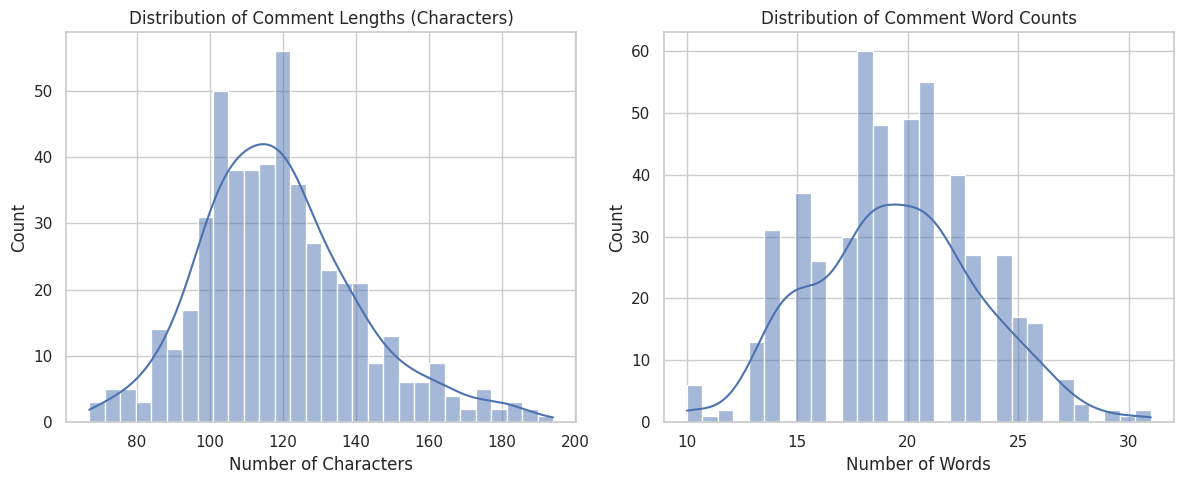

<Figure size 1400x700 with 0 Axes>

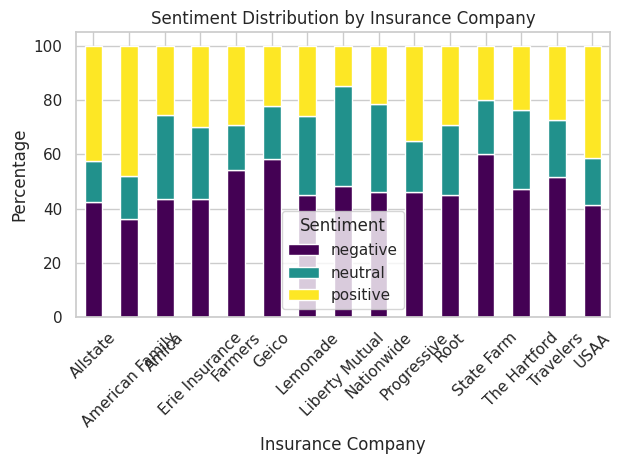

<Figure size 1400x700 with 0 Axes>

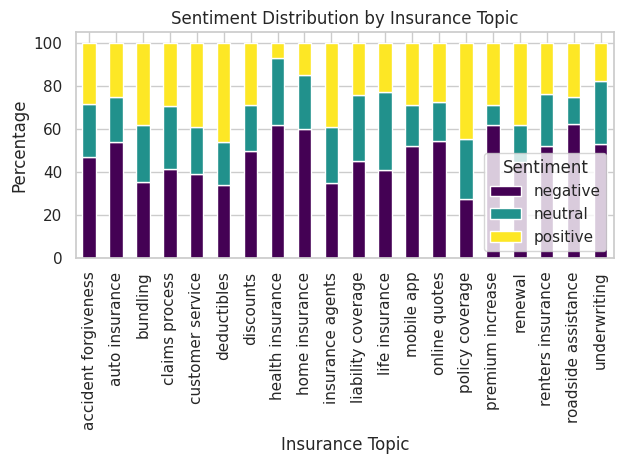


Top 20 words overall:
coverage: 79
service: 74
experience: 69
process: 68
make: 66
anyone: 64
customer: 61
switching: 59
difficult: 54
don: 53
state: 52
agents: 51
everything: 49
trying: 48
claim: 47
options: 45
know: 45
complaint: 44
claims: 42
allstate: 41


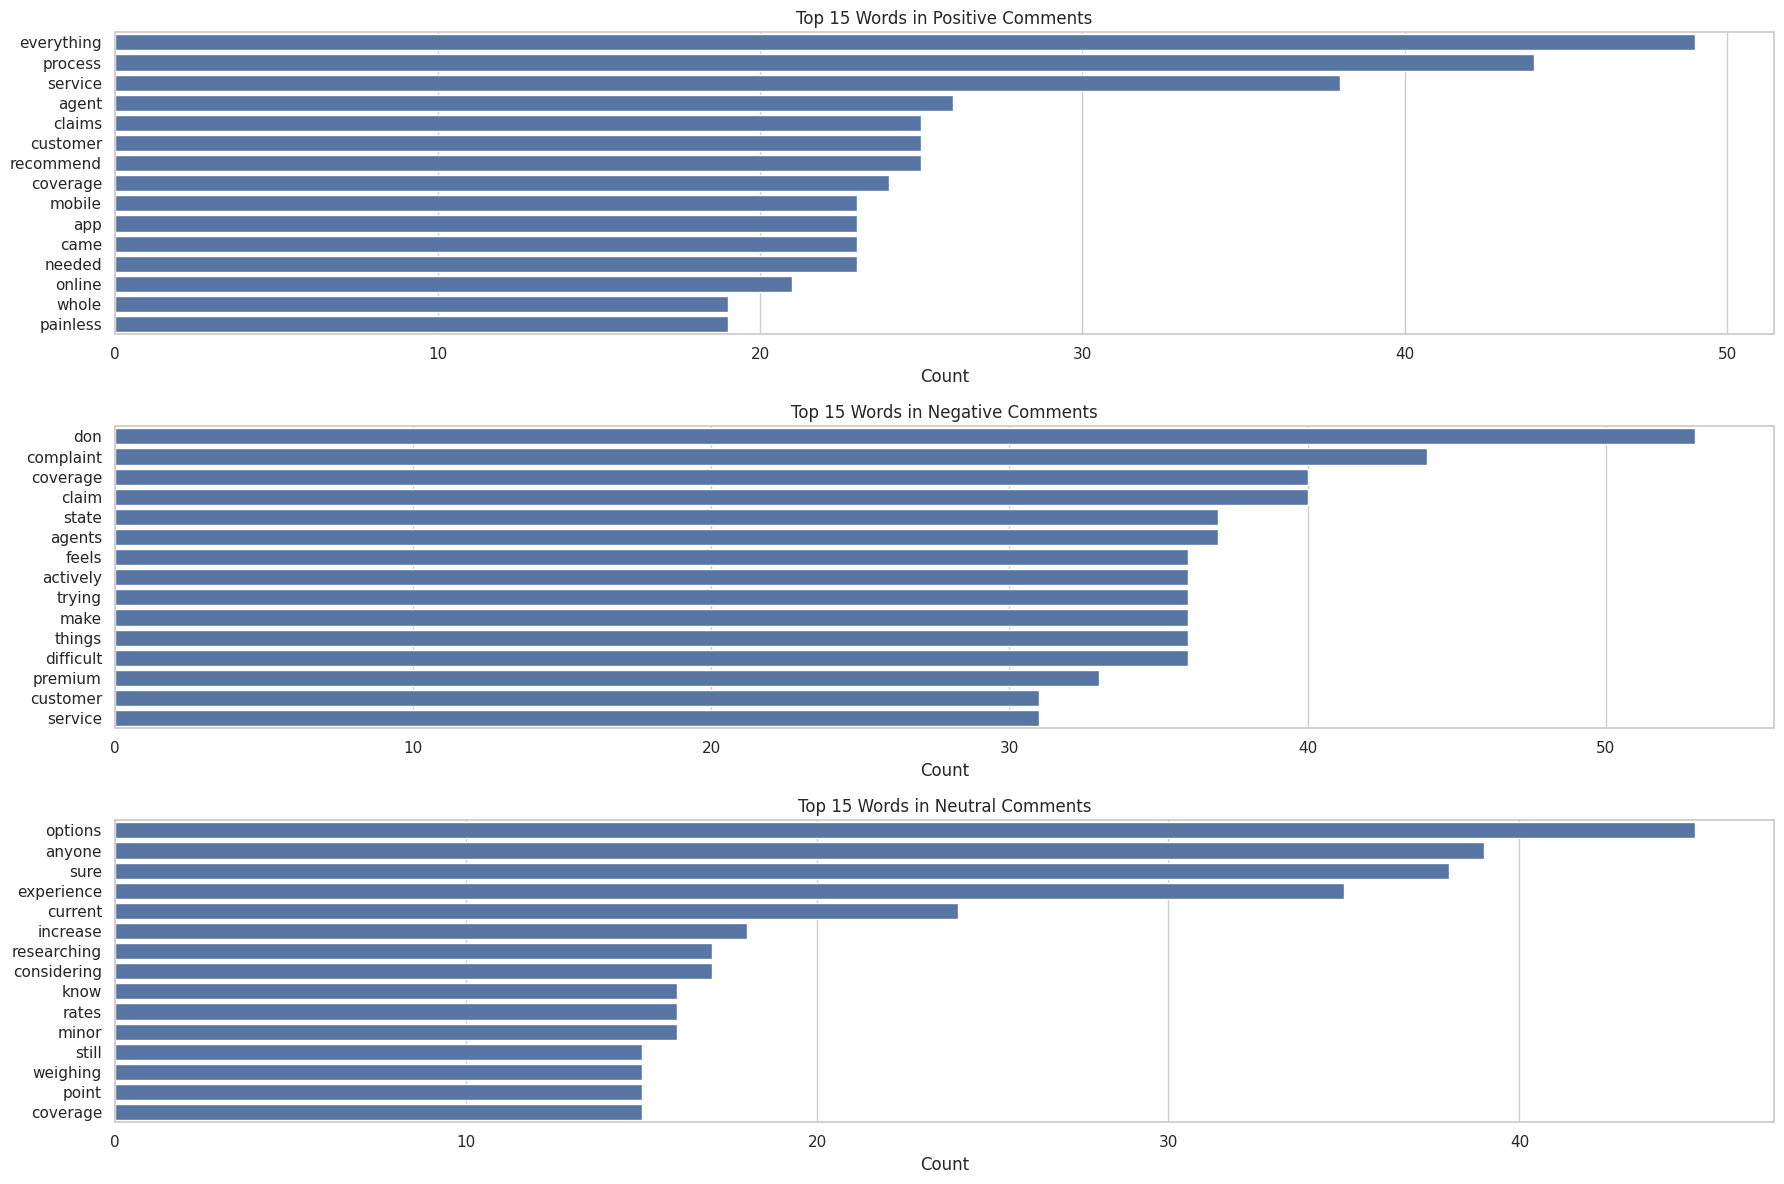

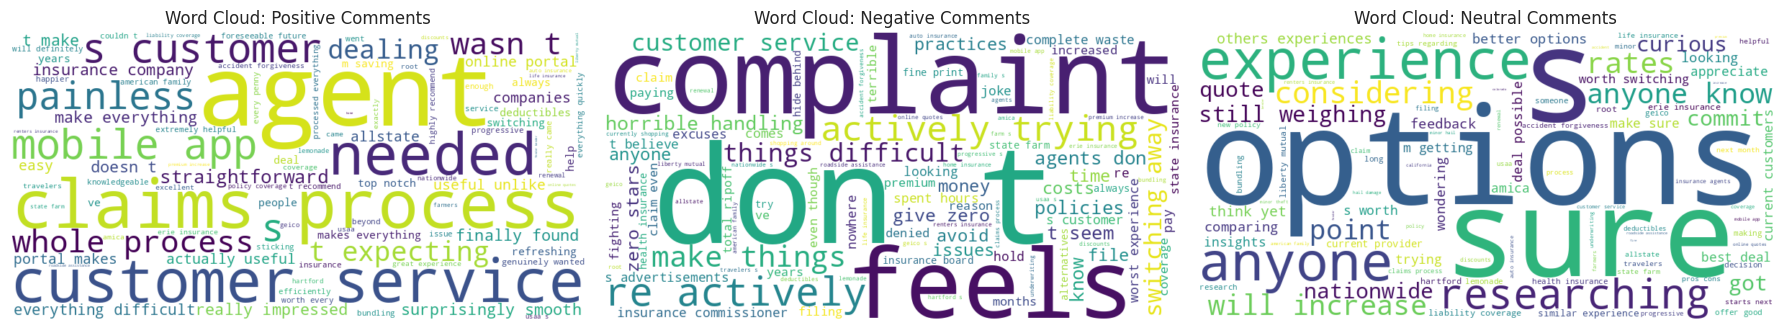

<Figure size 1400x700 with 0 Axes>

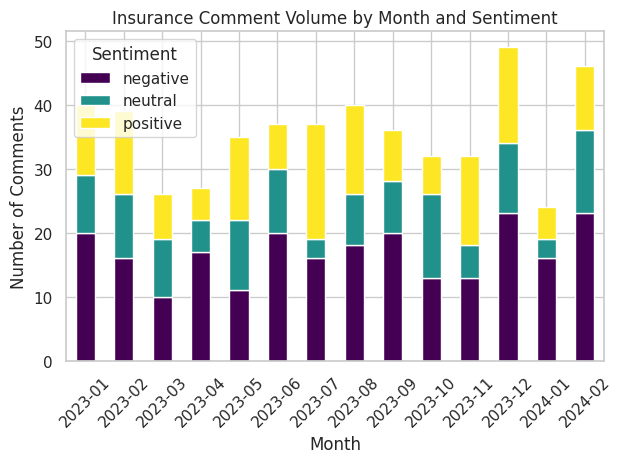

<Figure size 1200x600 with 0 Axes>

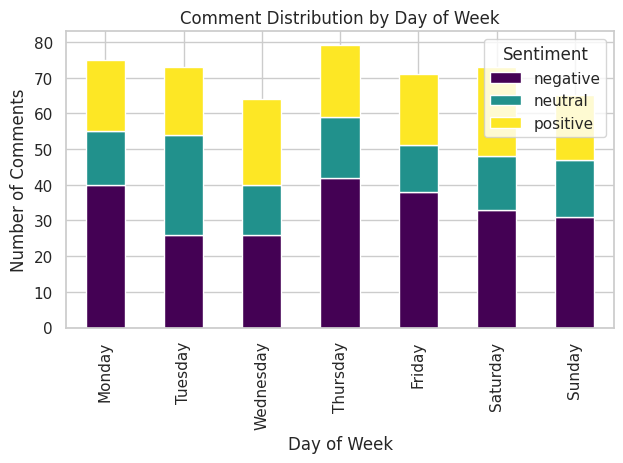


Correlation between text features and sentiment polarity:
comment_polarity    1.000000
comment_length      0.242918
word_count          0.129976
uppercase_ratio     0.060053
has_exclamation    -0.104931
Name: comment_polarity, dtype: float64

Processed dataset saved to: /content/data/processed_insurance_comments.csv
Processed dataset shape: (500, 15)

Sample of processed data:
                                                  text  \
306  Had to file a complaint with the insurance com...   
449  They denied my claim even though I've been pay...   
123  Avoid Erie Insurance at all costs! Their healt...   
194  Worst experience ever with Farmers's renewal. ...   
66   Finally found an insurance company that doesn'...   

                                            clean_text company_mentioned  \
306  had to file a complaint with the insurance com...        Nationwide   
449  they denied my claim even though i ve been pay...           Farmers   
123  avoid erie insurance at all costs the

In [6]:
# Step 3: Data Cleaning & Preprocessing (Fixed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from collections import Counter

# Install wordcloud if not already installed
!pip install -q wordcloud

# Load the synthetic data
df = pd.read_csv(f"{DATA_DIR}/synthetic_insurance_comments.csv")

print(f"Original dataset shape: {df.shape}")

# 3.1 Basic Data Cleaning
# ------------------------

# Check for missing values
print("\nMissing values in each column:")
print(df.isna().sum())

# Convert timestamp to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract additional time features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create a function to clean text
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        # Remove special characters and digits
        text = re.sub(r'[^\w\s]', ' ', text)
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ""

# Apply text cleaning
df['clean_text'] = df['text'].apply(clean_text)

# 3.2 Exploratory Data Analysis (EDA)
# -----------------------------------

# Display basic dataset statistics
print("\nBasic dataset statistics:")
print(df.describe(include='all').T)

# Get comment length statistics
df['comment_length'] = df['text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print("\nComment length statistics:")
print(f"Mean character length: {df['comment_length'].mean():.1f}")
print(f"Median character length: {df['comment_length'].median():.1f}")
print(f"Mean word count: {df['word_count'].mean():.1f}")
print(f"Median word count: {df['word_count'].median():.1f}")

# Plot the distribution of comment lengths
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['comment_length'], bins=30, kde=True)
plt.title('Distribution of Comment Lengths (Characters)')
plt.xlabel('Number of Characters')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Distribution of Comment Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Sentiment distribution by company
plt.figure(figsize=(14, 7))
company_sentiment = pd.crosstab(df['company_mentioned'], df['true_sentiment'], normalize='index') * 100
company_sentiment.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Sentiment Distribution by Insurance Company')
plt.xlabel('Insurance Company')
plt.ylabel('Percentage')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Topics by sentiment
plt.figure(figsize=(14, 7))
topic_sentiment = pd.crosstab(df['topic_discussed'], df['true_sentiment'], normalize='index') * 100
topic_sentiment.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Sentiment Distribution by Insurance Topic')
plt.xlabel('Insurance Topic')
plt.ylabel('Percentage')
plt.legend(title='Sentiment')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3.3 Text Analysis
# -----------------

# Function to get word frequencies without NLTK (avoiding the error)
def get_simple_word_frequencies(texts, top_n=30):
    # Simple list of common English stopwords
    stop_words = {'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
                 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
                 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
                 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
                 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
                 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such',
                 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can',
                 'will', 'just', 'should', 'now'}

    # Additional custom stopwords relevant to our domain
    custom_stopwords = {'insurance', 'company', 'policy', 'just', 'like', 'get', 'got', 'would',
                       'could', 'really', 'their', 'they', 'them', 'been', 'have', 'had', 'has',
                       'was', 'were', 'are', 'is', 'be', 'this', 'that', 'these', 'those', 'my',
                       'your', 'his', 'her', 'its', 'our', 'their', 'much', 'many', 'what', 'who'}

    all_stopwords = stop_words.union(custom_stopwords)

    # Tokenize and filter
    words = []
    for text in texts:
        # Simple tokenization by splitting on whitespace
        tokens = text.split()
        # Keep only alphabetic tokens that are not stopwords
        filtered_tokens = [word for word in tokens if word.isalpha() and word not in all_stopwords and len(word) > 2]
        words.extend(filtered_tokens)

    # Get word frequencies
    word_freq = Counter(words)

    # Return top N most common words
    return word_freq.most_common(top_n)

# Get overall word frequencies
print("\nTop 20 words overall:")
overall_word_freq = get_simple_word_frequencies(df['clean_text'], 20)
for word, count in overall_word_freq:
    print(f"{word}: {count}")

# Generate word frequencies by sentiment
sentiments = ['positive', 'negative', 'neutral']
sentiment_words = {}

for sentiment in sentiments:
    texts = df[df['true_sentiment'] == sentiment]['clean_text']
    sentiment_words[sentiment] = get_simple_word_frequencies(texts, 15)

# Plot word frequency by sentiment
plt.figure(figsize=(18, 12))

for i, sentiment in enumerate(sentiments, 1):
    plt.subplot(3, 1, i)
    words = [word for word, count in sentiment_words[sentiment]]
    counts = [count for word, count in sentiment_words[sentiment]]

    sns.barplot(x=counts, y=words)
    plt.title(f'Top 15 Words in {sentiment.capitalize()} Comments')
    plt.xlabel('Count')

plt.tight_layout()
plt.show()

# Generate word clouds for each sentiment
plt.figure(figsize=(18, 6))

for i, sentiment in enumerate(sentiments, 1):
    texts = ' '.join(df[df['true_sentiment'] == sentiment]['clean_text'])

    plt.subplot(1, 3, i)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis',
        contour_width=1,
        contour_color='steelblue'
    ).generate(texts)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud: {sentiment.capitalize()} Comments')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3.4 Analyze Insurance-Specific Patterns
# --------------------------------------

# Analyze comment patterns over time
plt.figure(figsize=(14, 7))
df_monthly = df.groupby([df['timestamp'].dt.to_period('M'), 'true_sentiment']).size().unstack()
df_monthly.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Insurance Comment Volume by Month and Sentiment')
plt.xlabel('Month')
plt.ylabel('Number of Comments')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of comments by day of week
plt.figure(figsize=(12, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sentiment = pd.crosstab(df['day_of_week'], df['true_sentiment'])
day_sentiment = day_sentiment.reindex(day_order)
day_sentiment.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Comment Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Comments')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# 3.5 Feature Engineering for Sentiment Analysis
# --------------------------------------------

# Create basic text features that might be useful for sentiment analysis
df['has_exclamation'] = df['text'].apply(lambda x: 1 if '!' in x else 0)
df['uppercase_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
df['comment_polarity'] = df['true_sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})

# Check if these features correlate with sentiment
print("\nCorrelation between text features and sentiment polarity:")
features = ['has_exclamation', 'uppercase_ratio', 'comment_length', 'word_count', 'comment_polarity']
print(df[features].corr()['comment_polarity'].sort_values(ascending=False))

# 3.6 Preparing Data for Next Steps
# --------------------------------

# Save the processed dataset
df.to_csv(f"{DATA_DIR}/processed_insurance_comments.csv", index=False)

print("\nProcessed dataset saved to:", f"{DATA_DIR}/processed_insurance_comments.csv")
print(f"Processed dataset shape: {df.shape}")

# Display a sample of the processed data
print("\nSample of processed data:")
sample_df = df[['text', 'clean_text', 'company_mentioned', 'topic_discussed', 'true_sentiment', 'comment_length', 'word_count']].sample(5)
print(sample_df)